In [ ]:
import os
import sys
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q pyspark mlflow seaborn pyyaml
except ImportError:
    pass

# Resolve project root without hardcoding: LAB3_PROJECT_ROOT env, else cwd detection, else prompt.
ROOT = os.environ.get("LAB3_PROJECT_ROOT")
if not ROOT:
    for cand in (Path.cwd(), *Path.cwd().parents):
        if (cand / "src" / "training.py").exists():
            ROOT = cand
            break
ROOT = Path(ROOT) if ROOT else Path(input("Path to project root (folder with src/): ").strip())

assert (ROOT / 'src').exists(), f"src/ not found under {ROOT}"
sys.path.insert(0, str(ROOT))
print("ROOT =", ROOT)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 148.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

 Training, Management, and Results

Train two `spark.ml` classifiers, rank by validation accuracy, register and promote the best to the MLflow Model Registry, then evaluate it. Training and results run in one session so the model artifacts stay available for B.3.

In [ ]:
import shutil

import mlflow
import mlflow.spark
import pandas as pd

from src.utils.config import load_config
from src.utils.spark_session import get_spark
from src import visuals
from src.training import (
    train, METRICS, SEED, load_training_df,
    confusion_matrix, label_order, per_class_metrics,
)

config = load_config()

## MLflow Tracking Store

`MLFLOW_TRACKING_URI` (env) or `config.mlflow.tracking_uri` selects a remote tracking server. Unset: local SQLite store synced to Drive, required because the Model Registry needs a SQL backend.

In [ ]:
remote_uri = os.environ.get("MLFLOW_TRACKING_URI") or config["mlflow"].get("tracking_uri")
experiment = config["mlflow"]["experiment"]
local_store = drive_store = None

if remote_uri:
    mlflow.set_tracking_uri(remote_uri)
    if mlflow.get_experiment_by_name(experiment) is None:
        mlflow.create_experiment(experiment)
    print("MLflow tracking ->", remote_uri)
else:
    drive_store = ROOT / "mlflow"
    local_store = Path("/content/mlflow") if Path("/content").exists() else drive_store
    if local_store != drive_store and drive_store.exists() and not local_store.exists():
        shutil.copytree(drive_store, local_store)
    local_store.mkdir(parents=True, exist_ok=True)
    mlflow.set_tracking_uri(f"sqlite:///{local_store / 'mlflow.db'}")
    if mlflow.get_experiment_by_name(experiment) is None:
        mlflow.create_experiment(experiment, artifact_location=str(local_store / "artifacts"))
    print("MLflow tracking -> sqlite:", local_store / "mlflow.db")

mlflow.set_experiment(experiment)

MLflow tracking -> sqlite: /content/mlflow/mlflow.db


<Experiment: artifact_location='/tmp/mlflow/artifacts', creation_time=1782328723816, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782328723816, lifecycle_stage='active', name='barcelona_price_tier', tags={}, trace_location=None, workspace='default'>

## Train, Rank, Deploy, Reload

Train both classifiers, log each run with its data fingerprint, promote the best by validation accuracy, then reload it from the registry to confirm reproducibility.

In [ ]:
spark = get_spark(config)
summary = train(spark, config)

print("data_fingerprint:", summary["fingerprint"])
for r in summary["results"]:
    print(f"  {r['name']:>20}  acc={r['accuracy']:.3f}  "
          f"recall={r['weightedRecall']:.3f}  f1={r['f1']:.3f}")
print("best:", summary["best"]["name"], "->", summary["model_uri"])
print("reloaded-from-registry acc:", round(summary["reload_metrics"]["accuracy"], 3))

Registered model 'barcelona_price_tier' already exists. Creating a new version of this model...
Created version '2' of model 'barcelona_price_tier'.
/content/drive/MyDrive/BSE/Big Data/Homework_Labs/Lab3-BigDataArchitectures/lab3-data-engineering/src/training.py:140: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(
2026/06/24 21:34:23 INFO mlflow.spark: URI 'models:/barcelona_price_tier/Production/sparkml' does not point to the current DFS.
2026/06/24 21:34:23 INFO mlflow.spark: File 'models:/barcelona_price_tier/Production/sparkml' not found on DFS. Will attempt to upload the file.


data_fingerprint: 87b1dc170d019a59
   logistic_regression  acc=0.722  recall=0.722  f1=0.724
         random_forest  acc=0.833  recall=0.833  f1=0.833
best: random_forest -> models:/barcelona_price_tier/Production
reloaded-from-registry acc: 0.833


## Results

Model comparison and best-model evaluation (confusion matrix, per-class metrics) on the validation split.

In [ ]:
comp = (pd.DataFrame(summary["results"])
        .rename(columns={"name": "model"})[["model", *METRICS]]
        .sort_values("accuracy", ascending=False)
        .reset_index(drop=True))
comp

,model,accuracy,weightedRecall,weightedPrecision,f1
0,random_forest,0.833333,0.833333,0.835468,0.833163
1,logistic_regression,0.722222,0.722222,0.727315,0.724381


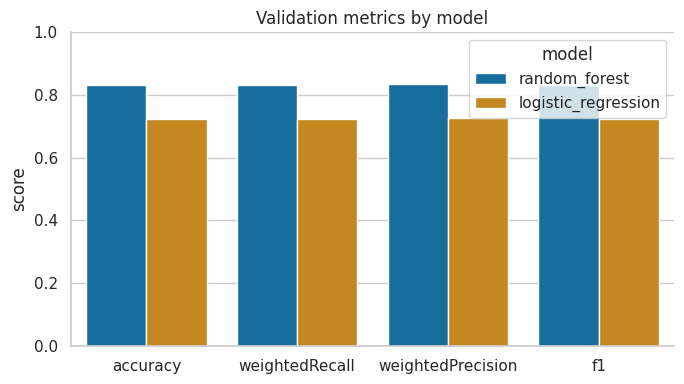

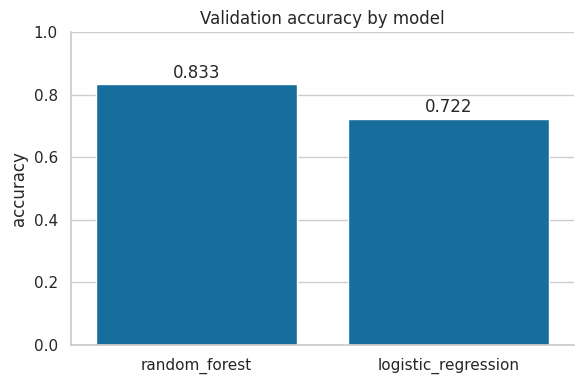

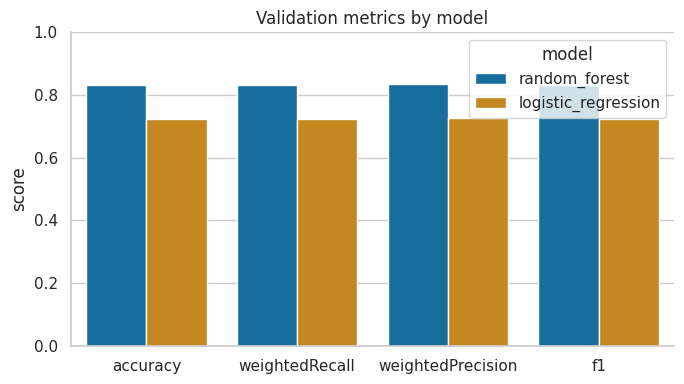

In [ ]:
visuals.plot_model_comparison(comp, "accuracy")
visuals.plot_metric_comparison(comp, METRICS)

### Best Model Performance

Confusion matrix and per-class recall/precision for the deployed model.

2026/06/24 21:34:26 INFO mlflow.spark: URI 'models:/barcelona_price_tier/Production/sparkml' does not point to the current DFS.
2026/06/24 21:34:26 INFO mlflow.spark: File 'models:/barcelona_price_tier/Production/sparkml' not found on DFS. Will attempt to upload the file.


,0
recall_mid,0.737
precision_mid,0.778
recall_high,0.889
precision_high,0.800
recall_low,0.882
precision_low,0.938


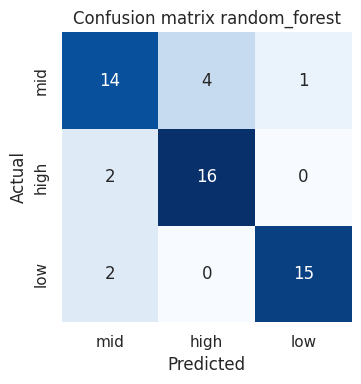

In [ ]:
model = mlflow.spark.load_model(summary["model_uri"])

df = load_training_df(spark, config)
df = df.orderBy(*df.columns)
frac = config["analysis"].get("train_fraction", 0.8)
_, val_df = df.randomSplit([frac, 1 - frac], seed=SEED)

preds = model.transform(val_df)
order = label_order(model)
visuals.plot_confusion_matrix(confusion_matrix(preds, order), order, summary["best"]["name"])
pd.Series(per_class_metrics(preds, order)).round(3)

In [ ]:
if not remote_uri and local_store != drive_store:
    shutil.rmtree(drive_store, ignore_errors=True)
    shutil.copytree(local_store, drive_store)
    print("synced MLflow store ->", drive_store)

synced MLflow store -> /content/drive/MyDrive/BSE/Big Data/Homework_Labs/Lab3-BigDataArchitectures/lab3-data-engineering/mlflow
